# Support Vector Machine

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
ruta = r'C:\docs\DOCTORADO\Machine_Learning/tornados.csv'  
df = pd.read_csv(ruta) 


## Máquinas de soporte vectorial (SVM)

In [268]:
import time
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd

# 1. Instanciamos el modelo SVM con kernel lineal
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

# 2. Medir tiempo de entrenamiento
start_time = time.time()
svm_linear.fit(X_train_scaled, y_train)
tiempo_entrenamiento = time.time() - start_time

# 3. Predecimos etiquetas y probabilidades
y_pred_svm = svm_linear.predict(X_test_scaled)
y_prob_svm = svm_linear.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluamos y guardamos métricas
resultados_svm_linear = pd.DataFrame({
    'Modelo': ['SVM (kernel linear, sin SMOTE)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_svm), 4)],
    'Precision': [round(precision_score(y_test, y_pred_svm), 4)],
    'Recall': [round(recall_score(y_test, y_pred_svm), 4)],
    'F1-score': [round(f1_score(y_test, y_pred_svm), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob_svm), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 5. Mostrar resultados
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_svm))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_svm))
display(resultados_svm_linear)



📊 Matriz de Confusión:
 [[12026     0]
 [  394    36]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     12026
           1       1.00      0.08      0.15       430

    accuracy                           0.97     12456
   macro avg       0.98      0.54      0.57     12456
weighted avg       0.97      0.97      0.96     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,"SVM (kernel linear, sin SMOTE)",0.9684,1.0,0.0837,0.1545,0.9016,38.0802


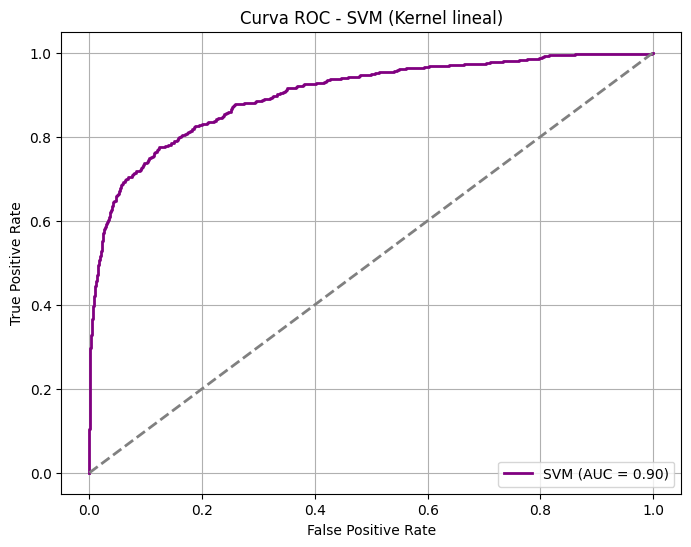

In [269]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcular FPR, TPR y AUC para el SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label='SVM (AUC = %0.2f)' % roc_auc_svm)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - SVM (Kernel lineal)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## SVM class_weight='balanced

Aplicaremos class_weight='balanced' para buscar un mejor recall para la clase 1:

In [278]:
import time
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd

# 1. Instanciar el modelo con balanceo de clases
svm_balanced = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)

# 2. Medir tiempo de entrenamiento
start_time = time.time()
svm_balanced.fit(X_train_scaled, y_train)
tiempo_entrenamiento = time.time() - start_time

# 3. Predecir etiquetas y probabilidades
y_pred_svm_bal = svm_balanced.predict(X_test_scaled)
y_prob_svm_bal = svm_balanced.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluar y guardar métricas
resultados_svm_bal = pd.DataFrame({
    'Modelo': ['SVM (kernel linear, class_weight=balanced)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_svm_bal), 4)],
    'Precision': [round(precision_score(y_test, y_pred_svm_bal), 4)],
    'Recall': [round(recall_score(y_test, y_pred_svm_bal), 4)],
    'F1-score': [round(f1_score(y_test, y_pred_svm_bal), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob_svm_bal), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 5. Mostrar resultados
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_svm_bal))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_svm_bal))
print (resultados_svm_bal)
display(resultados_svm_bal)


📊 Matriz de Confusión:
 [[10842  1184]
 [   68   362]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.99      0.90      0.95     12026
           1       0.23      0.84      0.37       430

    accuracy                           0.90     12456
   macro avg       0.61      0.87      0.66     12456
weighted avg       0.97      0.90      0.93     12456

                                       Modelo  Accuracy  Precision  Recall  \
0  SVM (kernel linear, class_weight=balanced)    0.8995     0.2342  0.8419   

   F1-score     AUC  CPU time (s)  
0    0.3664  0.9394      196.9632  


,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,"SVM (kernel linear, class_weight=balanced)",0.8995,0.2342,0.8419,0.3664,0.9394,196.9632


## SVM balanceado con SMOTE

Ahora vamos a probar con Smote

In [272]:
from imblearn.over_sampling import SMOTE # type: ignore
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import time  # <-- Para medir el tiempo

# 1. Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 2. Escalar los datos
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 3. Instanciar y entrenar el modelo SVM con medición de tiempo
start_time = time.time()

svm_smote = SVC(kernel='linear', probability=True, random_state=42)
svm_smote.fit(X_train_sm_scaled, y_train_sm)

end_time = time.time()
tiempo_entrenamiento = end_time - start_time

# 4. Predecir
y_pred = svm_smote.predict(X_test_scaled)
y_prob = svm_smote.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluar métricas y registrar resultados
resultados_svm_smote = pd.DataFrame({
    'Modelo': ['SVM (kernel linear, con SMOTE)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred), 4)],
    'Precision': [round(precision_score(y_test, y_pred), 4)],
    'Recall': [round(recall_score(y_test, y_pred), 4)],
    'F1-score': [round(f1_score(y_test, y_pred), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 6. Mostrar resultados
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred))
display(resultados_svm_smote)



📊 Matriz de Confusión:
 [[11939    87]
 [  249   181]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     12026
           1       0.68      0.42      0.52       430

    accuracy                           0.97     12456
   macro avg       0.83      0.71      0.75     12456
weighted avg       0.97      0.97      0.97     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,"SVM (kernel linear, con SMOTE)",0.973,0.6754,0.4209,0.5186,0.929,144.9095


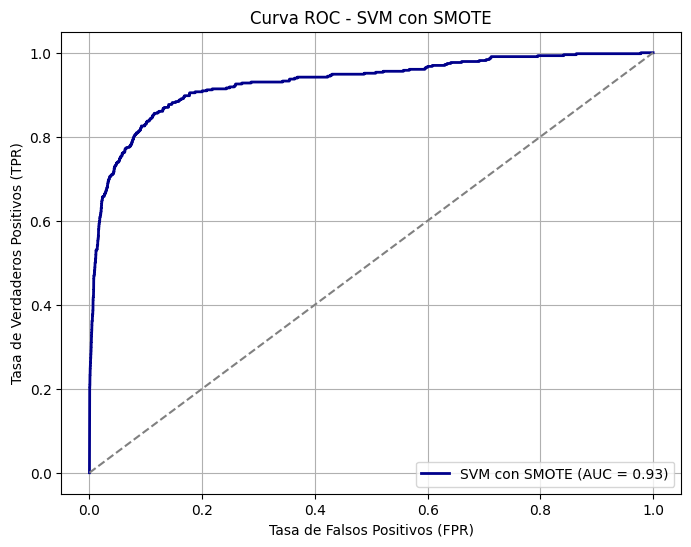

In [273]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calcular la curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 2. Graficar la curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkblue', lw=2, label='SVM con SMOTE (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - SVM con SMOTE')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## Aplicación de algoritmos de optimización 

SGD SVM SGDClassifier (Descenso de gradiente estocástico)

In [274]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import time
import pandas as pd

# 1. Instanciar modelo SGDClassifier como SVM lineal
sgd_svm = SGDClassifier(loss='hinge', random_state=42)

# 2. Medir tiempo de entrenamiento
start_time = time.time()
sgd_svm.fit(X_train_scaled, y_train)
tiempo_entrenamiento = time.time() - start_time

# 3. Predecir
y_pred_sgd = sgd_svm.predict(X_test_scaled)

# 4. Probabilidades (usamos decision_function para aproximar AUC)
y_scores = sgd_svm.decision_function(X_test_scaled)

# 5. Evaluar y mostrar resultados
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_sgd))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_sgd))

# 6. Crear DataFrame con métricas
resultados_sgd_svm = pd.DataFrame({
    'Modelo': ['SVM con SGDClassifier'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_sgd), 4)],
    'Precision': [round(precision_score(y_test, y_pred_sgd, zero_division=0), 4)],
    'Recall': [round(recall_score(y_test, y_pred_sgd), 4)],
    'F1-score': [round(f1_score(y_test, y_pred_sgd), 4)],
    'AUC': [round(roc_auc_score(y_test, y_scores), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 7. Mostrar métricas en tabla
print("\n📈 Resultados:")
display(resultados_sgd_svm)


📊 Matriz de Confusión:
 [[12023     3]
 [  370    60]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     12026
           1       0.95      0.14      0.24       430

    accuracy                           0.97     12456
   macro avg       0.96      0.57      0.61     12456
weighted avg       0.97      0.97      0.96     12456


📈 Resultados:


,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,SVM con SGDClassifier,0.9701,0.9524,0.1395,0.2434,0.8548,0.1687


## LinearSVC

In [275]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
import time

# Medir tiempo de entrenamiento
inicio = time.time()

# Entrenamos con LinearSVC (no tiene predict_proba, así que usamos CalibratedClassifierCV)
linear_svc_base = LinearSVC(random_state=42, max_iter=10000)
calibrated_svc = CalibratedClassifierCV(linear_svc_base, cv=5)
calibrated_svc.fit(X_train_scaled, y_train)

fin = time.time()
tiempo_entrenamiento = fin - inicio

# Predecir
y_pred_linear_svc = calibrated_svc.predict(X_test_scaled)
y_prob_linear_svc = calibrated_svc.predict_proba(X_test_scaled)[:, 1]

# Guardar métricas
resultados_linear_svc = pd.DataFrame({
    'Modelo': ['LinearSVC (con calibración)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_linear_svc), 4)],
    'Precision': [round(precision_score(y_test, y_pred_linear_svc), 4)],
    'Recall': [round(recall_score(y_test, y_pred_linear_svc), 4)],
    'F1-score': [round(f1_score(y_test, y_pred_linear_svc), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob_linear_svc), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# Verificar matriz y reporte si quieres
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_linear_svc))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_linear_svc))

display(resultados_linear_svc)

📊 Matriz de Confusión:
 [[12024     2]
 [  378    52]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     12026
           1       0.96      0.12      0.21       430

    accuracy                           0.97     12456
   macro avg       0.97      0.56      0.60     12456
weighted avg       0.97      0.97      0.96     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,LinearSVC (con calibración),0.9695,0.963,0.1209,0.2149,0.919,3.4848


## RBF con Random Fourier Features

In [276]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import time

# Escalarlos  datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Crear pipeline con RBFSampler y SGDClassifier
rbf_feature = RBFSampler(gamma=1, random_state=42)
clf_rbf_sgd = make_pipeline(rbf_feature, SGDClassifier(max_iter=1000, tol=1e-3, random_state=42))

# 2. Entrenar el modelo y registrar tiempo de CPU
start_time = time.time()
clf_rbf_sgd.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

# 3. Predecir en el conjunto de prueba
y_pred_rbf = clf_rbf_sgd.predict(X_test_scaled)
y_score_rbf = clf_rbf_sgd.decision_function(X_test_scaled)  # Necesario para AUC

# 4. Calcular métricas
accuracy = round(accuracy_score(y_test, y_pred_rbf), 4)
precision = round(precision_score(y_test, y_pred_rbf), 4)
recall = round(recall_score(y_test, y_pred_rbf), 4)
f1 = round(f1_score(y_test, y_pred_rbf), 4)
auc = round(roc_auc_score(y_test, y_score_rbf), 4)

# 5. Crear DataFrame con resultados
resultados_rbf = pd.DataFrame({
    'Modelo': ['SVM (RBF approx con Random Fourier)'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-score': [f1],
    'AUC': [auc],
    'CPU time (s)': [round(training_time, 4)]
})

# 6. Mostrar matriz de confusión y reporte
print("📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_rbf))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_rbf))

# 7. Ver resultados en tabla
resultados_rbf


📊 Matriz de Confusión:
 [[12026     0]
 [  430     0]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     12026
           1       0.00      0.00      0.00       430

    accuracy                           0.97     12456
   macro avg       0.48      0.50      0.49     12456
weighted avg       0.93      0.97      0.95     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,SVM (RBF approx con Random Fourier),0.9655,0.0,0.0,0.0,0.502,0.1191


## Aplicación de Pipeline y Gridsearch 

In [1]:
# 📦 LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import glob
from joblib import dump, load
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# 📂 CARGA DE DATOS
ruta = r'C:\docs\DOCTORADO\Machine_Learning\tornados.csv'
df = pd.read_csv(ruta)
df['mortality'] = np.where(df['fat'] == 0, 0, 1)

In [2]:
# 🧹 PREPROCESAMIENTO
df_ml = df.copy()
df_ml.drop(['om', 'date', 'time', 'datetime_utc', 'stf', 'fat', 'f1', 'f2', 'f3', 'f4'], axis=1, inplace=True)
df_ml.dropna(inplace=True)
df_ml['fc'] = df_ml['fc'].astype(int)
df_ml = pd.get_dummies(df_ml, columns=['st', 'tz'], drop_first=True)
df_ml.replace({False: 0, True: 1}, inplace=True)

C:\Users\Yuliceth Ramos\AppData\Local\Temp\ipykernel_5340\1702169410.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ml.replace({False: 0, True: 1}, inplace=True)


In [3]:
# 📊 SEPARACIÓN
X = df_ml.drop('mortality', axis=1)
y = df_ml['mortality']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [4]:
# 🔁 PIPELINE Y GRIDSEARCHCV
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

grid = None
if len(glob.glob("grid_svm.joblib")) != 0:
    grid = load("grid_svm.joblib")
else:
    time_start = time.process_time()
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    time_stop = time.process_time()

    print("Tiempo total (CPU):", round((time_stop - time_start), 2), "s")
    dump(grid, "grid_svm.joblib")

Tiempo total (CPU): 35.92 s


In [5]:
# 🔍 EVALUACIÓN
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

resultados_SVM_pip_grid = pd.DataFrame({
    'Modelo': ['SVM + GridSearch'],
    'Accuracy': [round(accuracy_score(y_test, y_pred), 4)],
    'Precision': [round(precision_score(y_test, y_pred), 4)],
    'Recall': [round(recall_score(y_test, y_pred), 4)],
    'F1-score': [round(f1_score(y_test, y_pred), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob), 4)],
    'CPU time (s)': [round((time_stop - time_start), 2)]
})

display(resultados_SVM_pip_grid)


,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,SVM + GridSearch,0.9713,0.8214,0.214,0.3395,0.9306,35.92


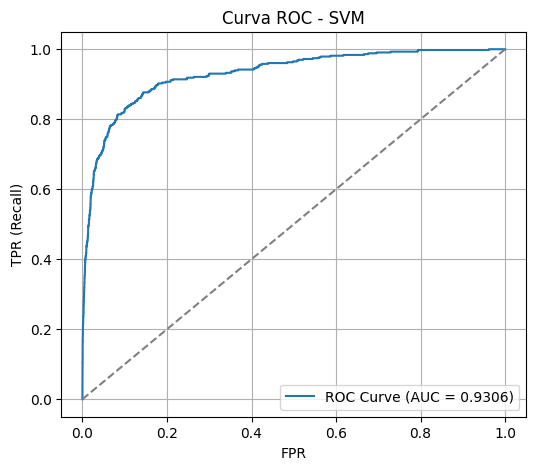

In [6]:
# 📈 CURVA ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR (Recall)')
plt.title('Curva ROC - SVM')
plt.legend()
plt.grid(True)
plt.show()

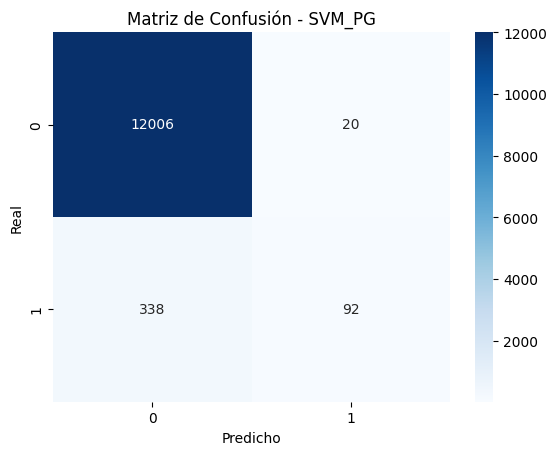

In [7]:
# 🔲 MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.title('Matriz de Confusión - SVM_PG')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()